In [2]:
'''
Dataset:
Data Understaing--  Numeric col
Data cleaning -- missing vals, duplicates, remove /5,RS symbol,
Create one cost category low , med , high
Rating category - poor <2 avg<4 excellent>4
Online order - encode it 
Book table - encode it 


EDA
-->Location Analysis - 2 bar charts Rest count by loc , avg rating by location 
-->Rating analysis - Histogram for distribution, Box plot which restaurant have highest rating, cost vs rating scatter plot
restaurat types count plot, avg rating by time, top 10 restaurant bar chart , scatter plot of votes vs rating 


Does online order affter rating, 
Does table boooking affect rating,
scatter plot of cost vs rating 
Do expensive rest have higer rating 
Does higher vote means better rating 
Heat maps 
'''

'\nDataset:\nData Understaing--  Numeric col\nData cleaning -- missing vals, duplicates, remove /5,RS symbol,\nCreate one cost category low , med , high\nRating category - poor <2 avg<4 excellent>4\nOnline order - encode it \nBook table - encode it \n\n\nEDA\n-->Location Analysis - 2 bar charts Rest count by loc , avg rating by location \n-->Rating analysis - Histogram for distribution, Box plot which restaurant have highest rating, cost vs rating scatter plot\nrestaurat types count plot, avg rating by time, top 10 restaurant bar chart , scatter plot of votes vs rating \n\n\nDoes online order affter rating, \nDoes table boooking affect rating,\nscatter plot of cost vs rating \nDo expensive rest have higer rating \nDoes higher vote means better rating \nHeat maps \n'

In [3]:
import pandas as pd

df=pd.read_csv('/home/nineleaps/Downloads/archive (4)/zomato.csv')

In [4]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [6]:
df.dtypes


url                              str
address                          str
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
phone                            str
location                         str
rest_type                        str
dish_liked                       str
cuisines                         str
approx_cost(for two people)      str
reviews_list                     str
menu_item                        str
listed_in(type)                  str
listed_in(city)                  str
dtype: object

In [7]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [8]:
df.drop(columns=['url','phone','reviews_list','menu_item'],inplace=True)

In [9]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [10]:
df.isnull().sum()

address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [11]:
df.dtypes

address                          str
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
location                         str
rest_type                        str
dish_liked                       str
cuisines                         str
approx_cost(for two people)      str
listed_in(type)                  str
listed_in(city)                  str
dtype: object

In [12]:
df['rate'] = df['rate'].str.split('/').str[0]

In [13]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [14]:
duplicates = df[df.duplicated()]

print(duplicates)

                                                 address  \
596    572, 30th Main, 3rd Stage, Banashankari, Banga...   
3763   26, Opposite Shubh Enclave, Ambalipura Village...   
4949   26, Varthur Hobli, Near HP Petrol Bunk, Harlur...   
4950   20\5, Panathur Junction, Outer Ring Road, Kadu...   
4969   20\5, Panathur Junction, Outer Ring Road, Kadu...   
...                                                  ...   
46065  2008, 2nd Floor, 100 Feet Road, Indiranagar, B...   
46066  776, 3rd Floor, 100 Feet Road, Indiranagar, Ba...   
46118  1200, 100 Feet Road, HAL 2nd Stage, Indiranaga...   
48777         Level 5, Eva Mall, Brigade Road, Bangalore   
50904  17, Thubarahalli Village, Hobli, Varthur Main ...   

                                name online_order book_table  rate  votes  \
596                     My Tea House          Yes        Yes   NaN      0   
3763           The Fisherman's Wharf          Yes        Yes   4.4   4099   
4949                       OPUS Club           N

In [15]:
# This keeps the first occurrence and deletes the rest
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet,Banashankari


In [18]:
print(df.isnull().sum())
print(len(df))

address                            0
name                               0
online_order                       0
book_table                         0
rate                           10030
votes                              0
location                          21
rest_type                        227
dish_liked                     28037
cuisines                          45
approx_cost(for two people)      344
listed_in(type)                    0
listed_in(city)                    0
dtype: int64
51632


In [19]:
df['dish_liked']=df['dish_liked'].fillna("Unknown")

In [20]:
df.dropna(subset=['location', 'rest_type',], inplace=True)

In [21]:
df.drop(columns='cuisines',inplace=True)

In [22]:
df['approx_cost(for two people)']

0          800
1          800
2          800
3          300
4          600
         ...  
51712    1,500
51713      600
51714    2,000
51715    2,500
51716    1,500
Name: approx_cost(for two people), Length: 51405, dtype: str

In [23]:
# 1. Remove commas and 'Rs' using regex
# [,] matches commas, and [Rs] matches R or s
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(r'[Rs,]', '', regex=True)

# 2. Convert to numeric
# errors='coerce' turns any remaining non-numeric text into NaN
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# 3. Check the result
print(df['approx_cost(for two people)'].dtype)

float64


In [24]:
df.rename(columns={'approx_cost(for two people)': 'cost'}, inplace=True)

In [25]:
# Calculate median for the cost column
cost_median = df['cost'].median()

# Fill nulls
df['cost'] = df['cost'].fillna(cost_median)

In [26]:
# Fill nulls using the median of their specific 'location'
df['rate'] = df['rate'].fillna(df.groupby('location')['rate'].transform('median'))

In [27]:
df[df['rate'].isnull()]

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cost,listed_in(type),listed_in(city)
15250,"Shreyas 3rd Cross, Shabari Layout, Venkteshwar...",Red Savina,No,No,NaN,0,Jakkur,Delivery,Unknown,400.0,Delivery,Frazer Town
24419,"Shreyas 3rd Cross, Shabari Layout, Venkteshwar...",Red Savina,No,No,NaN,0,Jakkur,Delivery,Unknown,400.0,Delivery,Kalyan Nagar
25691,"Shreyas 3rd Cross, Shabari Layout, Venkteshwar...",Red Savina,No,No,NaN,0,Jakkur,Delivery,Unknown,400.0,Delivery,Kammanahalli


In [28]:
df[df['location']=='Jakkur']

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cost,listed_in(type),listed_in(city)
15250,"Shreyas 3rd Cross, Shabari Layout, Venkteshwar...",Red Savina,No,No,NaN,0,Jakkur,Delivery,Unknown,400.0,Delivery,Frazer Town
24419,"Shreyas 3rd Cross, Shabari Layout, Venkteshwar...",Red Savina,No,No,NaN,0,Jakkur,Delivery,Unknown,400.0,Delivery,Kalyan Nagar
25691,"Shreyas 3rd Cross, Shabari Layout, Venkteshwar...",Red Savina,No,No,NaN,0,Jakkur,Delivery,Unknown,400.0,Delivery,Kammanahalli


In [29]:
df['rate']=df['rate'].dropna()

In [30]:
df.dtypes

address                str
name                   str
online_order           str
book_table             str
rate               float64
votes                int64
location               str
rest_type              str
dish_liked             str
cost               float64
listed_in(type)        str
listed_in(city)        str
dtype: object

In [31]:
df.drop(columns='dish_liked',inplace=True)

In [32]:
# 1. Cost Category: Low, Med, High
# We use quantiles (qcut) to ensure an even distribution, 
# or 'cut' if you have specific price points in mind.
df['cost_category'] = pd.qcut(df['cost'], 3, labels=['low', 'med', 'high'])


In [33]:
df['rate']

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    3.6
51714    3.6
51715    4.3
51716    3.4
Name: rate, Length: 51405, dtype: float64

In [34]:
# Convert rate to float (this fixes the 'object' issue)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')



In [35]:
# 1. Rating Category (Manual Bins)
# We use -1 as the start to catch 0s, or 0 if 0 is your lowest
df['rating_category'] = pd.cut(df['rate'], 
                               bins=[0, 2, 4, 5], 
                               labels=['poor', 'avg', 'excellent'])

In [36]:
# Simple Map for Online Order
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})

# Get Dummies for Book Table
# This creates a 'book_table_Yes' column (1 for Yes, 0 for No)
df = pd.get_dummies(df, columns=['book_table'], drop_first=True)

In [37]:
df=df.dropna()

In [38]:
df.isnull().sum()

address            0
name               0
online_order       0
rate               0
votes              0
location           0
rest_type          0
cost               0
listed_in(type)    0
listed_in(city)    0
cost_category      0
rating_category    0
book_table_Yes     0
dtype: int64

In [39]:
df.head()

,address,name,online_order,rate,votes,location,rest_type,cost,listed_in(type),listed_in(city),cost_category,rating_category,book_table_Yes
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,4.1,775,Banashankari,Casual Dining,800.0,Buffet,Banashankari,high,excellent,True
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,4.1,787,Banashankari,Casual Dining,800.0,Buffet,Banashankari,high,excellent,False
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,3.8,918,Banashankari,"Cafe, Casual Dining",800.0,Buffet,Banashankari,high,avg,False
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,3.7,88,Banashankari,Quick Bites,300.0,Buffet,Banashankari,low,avg,False
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,3.8,166,Basavanagudi,Casual Dining,600.0,Buffet,Banashankari,med,avg,False


In [40]:
df.dtypes

address                 str
name                    str
online_order          int64
rate                float64
votes                 int64
location                str
rest_type               str
cost                float64
listed_in(type)         str
listed_in(city)         str
cost_category      category
rating_category    category
book_table_Yes         bool
dtype: object

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Safety: Ensure bools are numeric for the heatmap later
df['book_table_Yes'] = df['book_table_Yes'].astype(int)

# Set the visual style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

/tmp/ipykernel_63196/412040005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='location', order=df['location'].value_counts().index[:15], ax=ax[0], palette='viridis')
/tmp/ipykernel_63196/412040005.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_rating.values, y=loc_rating.index, ax=ax[1], palette='magma')


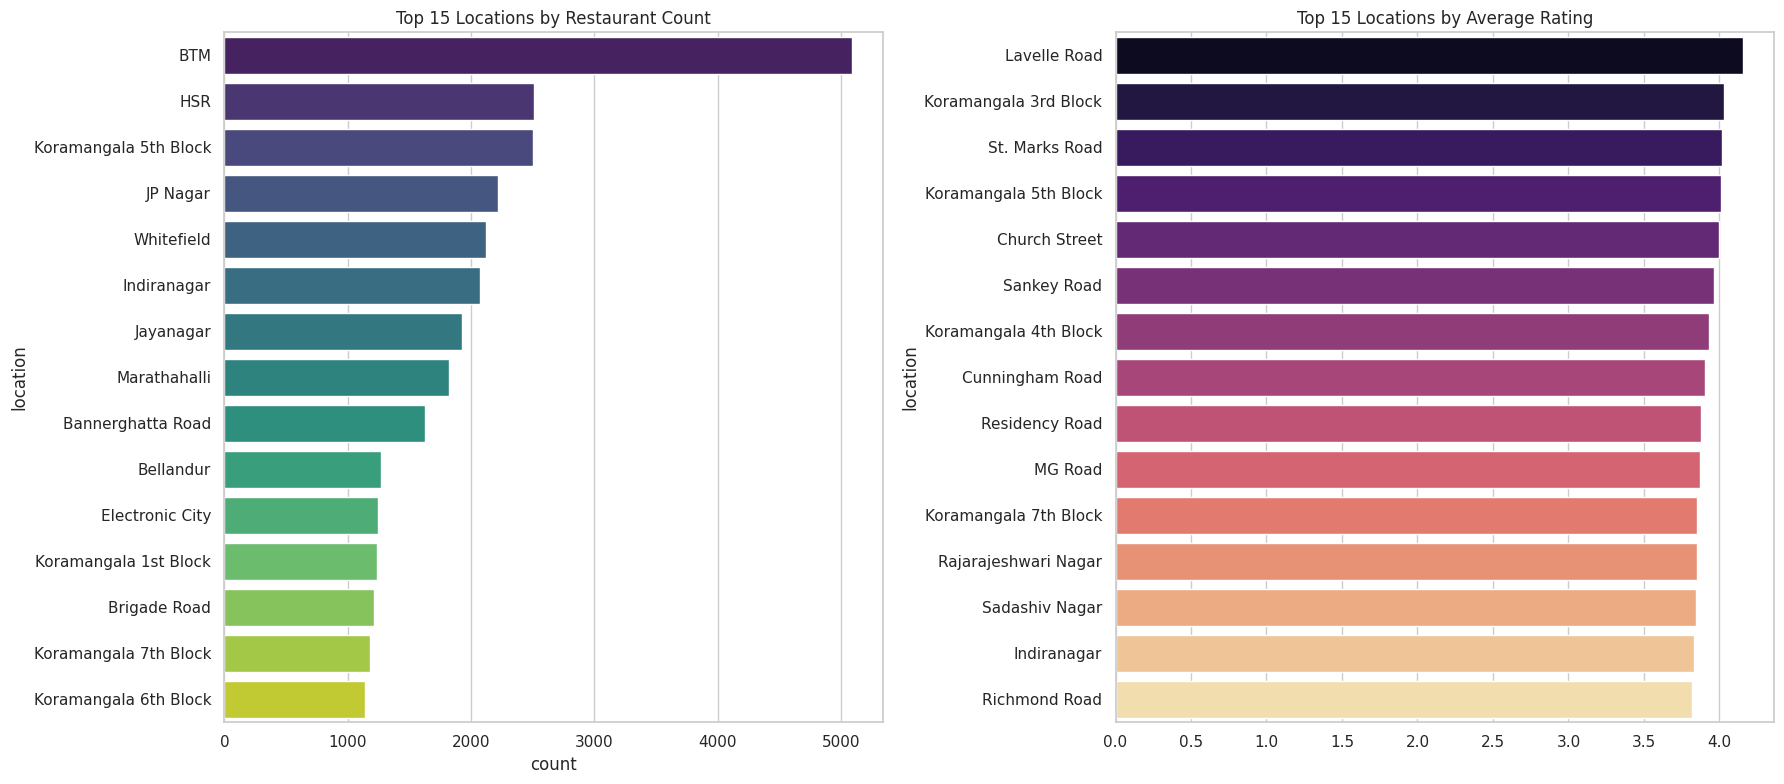

In [42]:
#Location Analysis

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# 1. Restaurant Count by Location (Top 15 for readability)
sns.countplot(data=df, y='location', order=df['location'].value_counts().index[:15], ax=ax[0], palette='viridis')
ax[0].set_title('Top 15 Locations by Restaurant Count')

# 2. Avg Rating by Location
loc_rating = df.groupby('location')['rate'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=loc_rating.values, y=loc_rating.index, ax=ax[1], palette='magma')
ax[1].set_title('Top 15 Locations by Average Rating')

plt.tight_layout()
plt.show()

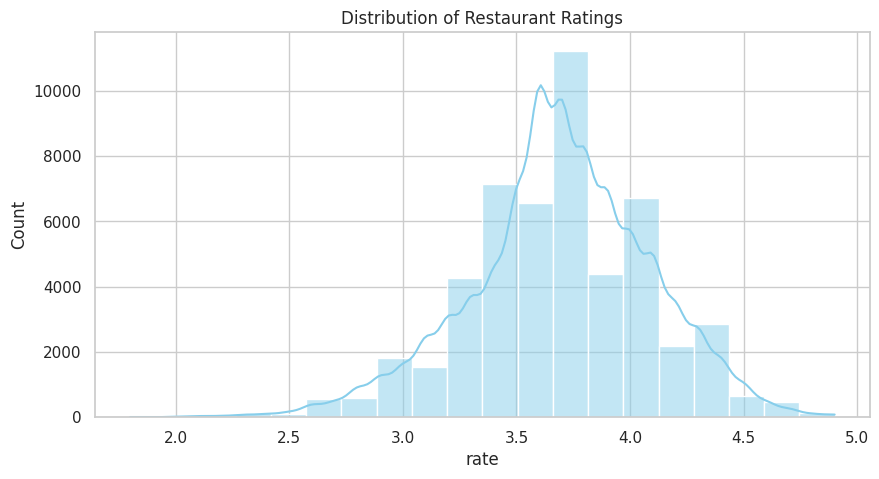

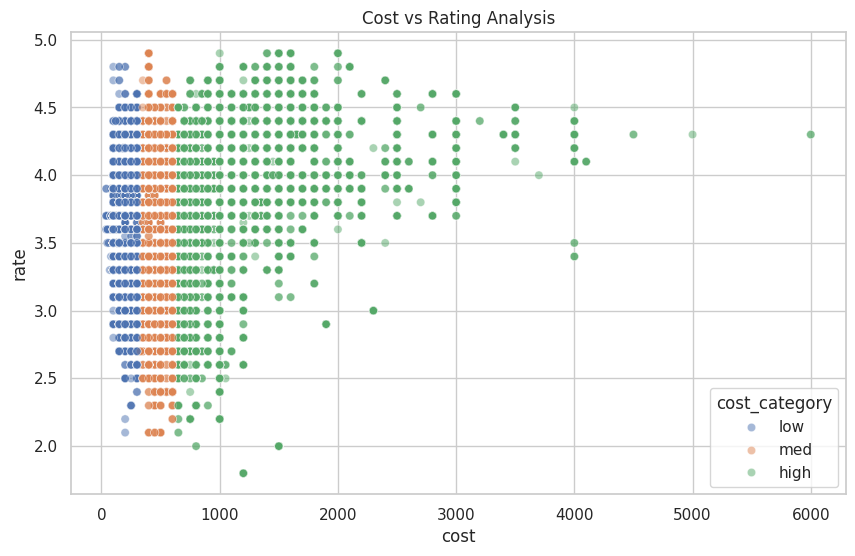

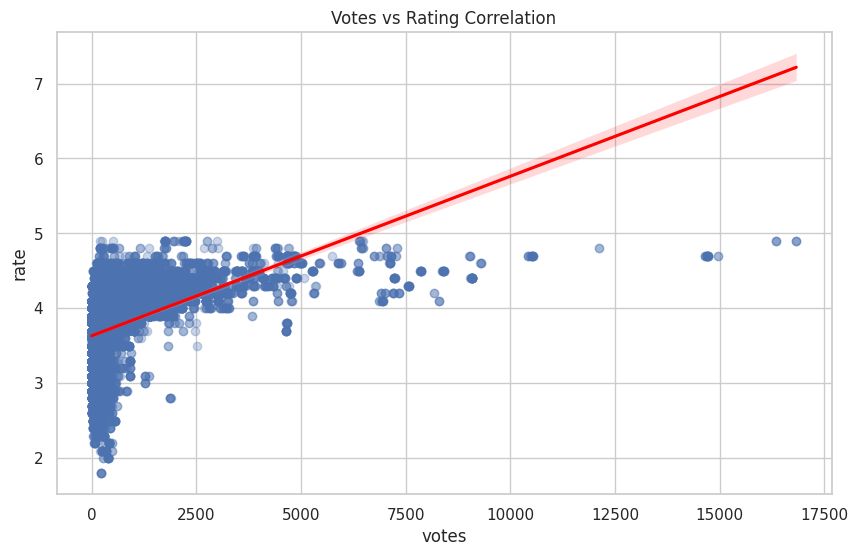

In [43]:
#Rating & Cost Analysis

# 1. Distribution of Ratings (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['rate'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Restaurant Ratings')
plt.show()

# 2. Cost vs Rating (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='cost', y='rate', hue='cost_category', alpha=0.5)
plt.title('Cost vs Rating Analysis')
plt.show()

# 3. Votes vs Rating (Does more popularity = better quality?)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='votes', y='rate', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Votes vs Rating Correlation')
plt.show()

/tmp/ipykernel_63196/3656500933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cost_category', y='rate', palette='Set2')


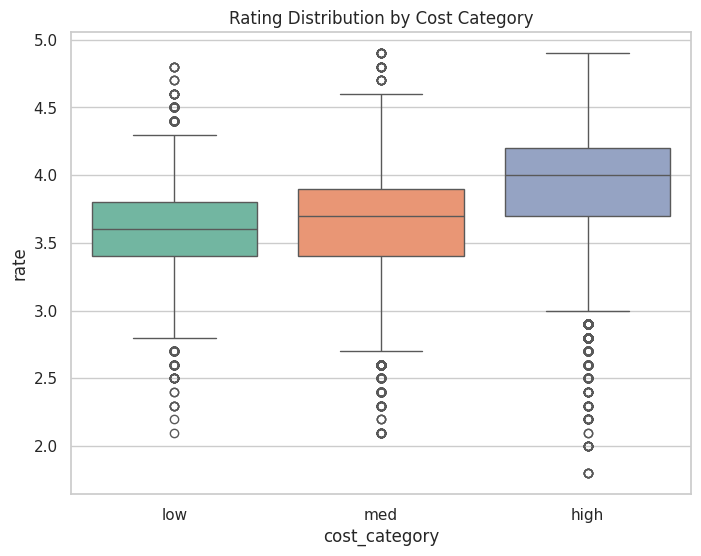

In [44]:
#Do expensive restaurants have higher ratings?
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='cost_category', y='rate', palette='Set2')
plt.title('Rating Distribution by Cost Category')
plt.show()

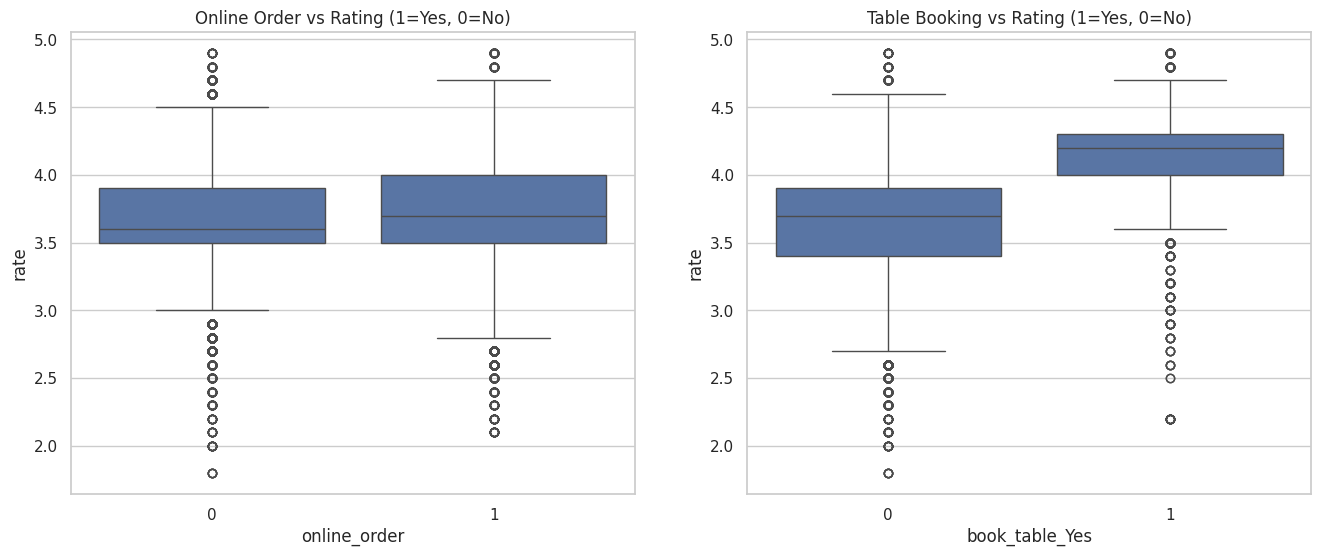

In [45]:
#Does Online Order or Table Booking affect ratings?
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='online_order', y='rate', ax=ax[0])
ax[0].set_title('Online Order vs Rating (1=Yes, 0=No)')

sns.boxplot(data=df, x='book_table_Yes', y='rate', ax=ax[1])
ax[1].set_title('Table Booking vs Rating (1=Yes, 0=No)')
plt.show()

/tmp/ipykernel_63196/3765605767.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='rate', y='name', palette='coolwarm')


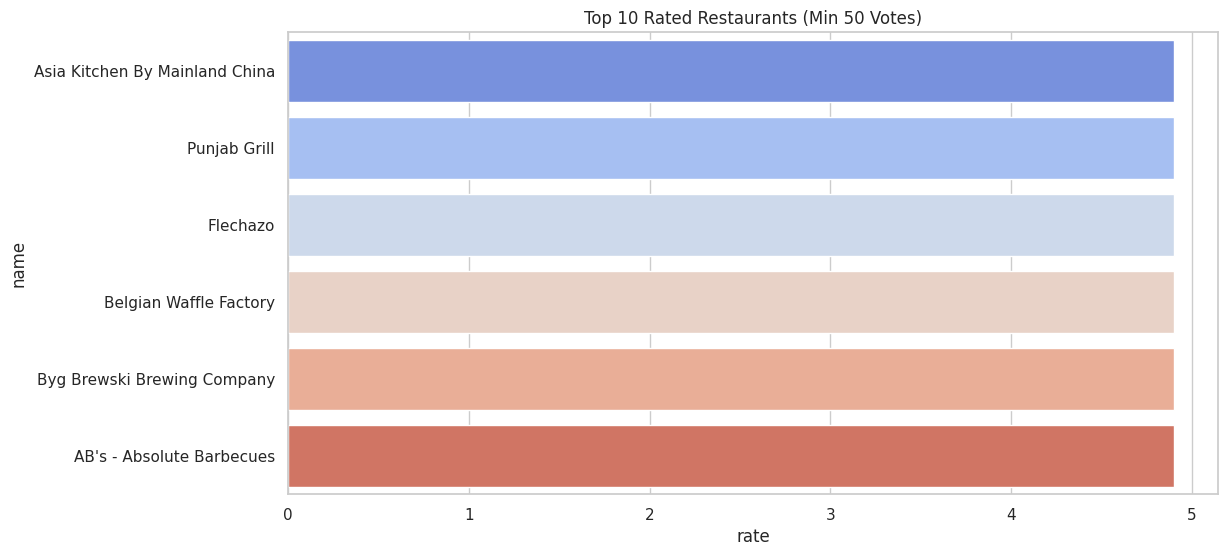

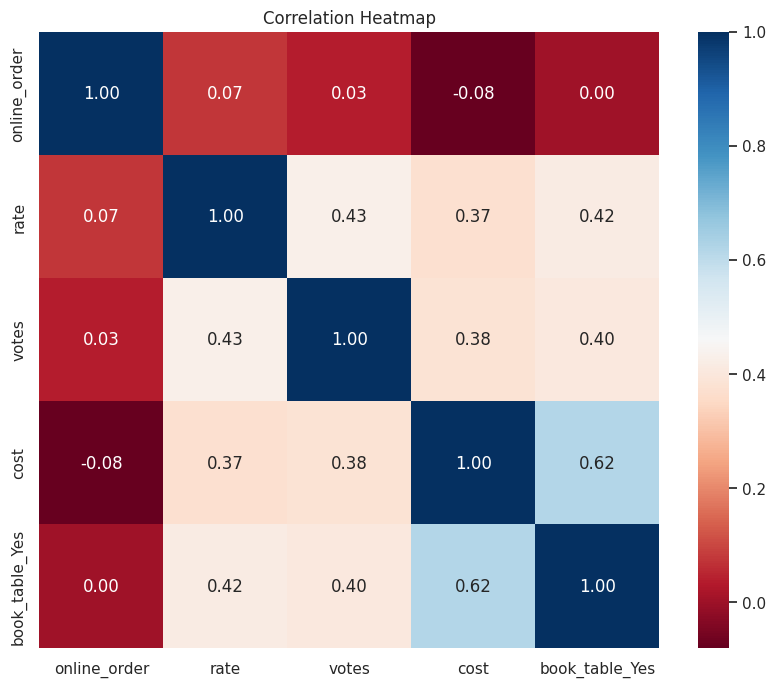

In [51]:
#Advanced EDA: Heatmap & Restaurant Types

# 1. Top 10 Restaurants by Rating (filtering for those with high votes to avoid bias)
top_10 = df[df['votes'] > 50].sort_values(by='rate', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='rate', y='name', palette='coolwarm')
plt.title('Top 10 Rated Restaurants (Min 50 Votes)')
plt.show()

# 2. Heatmap of Correlations
plt.figure(figsize=(10, 8))
# Only include numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

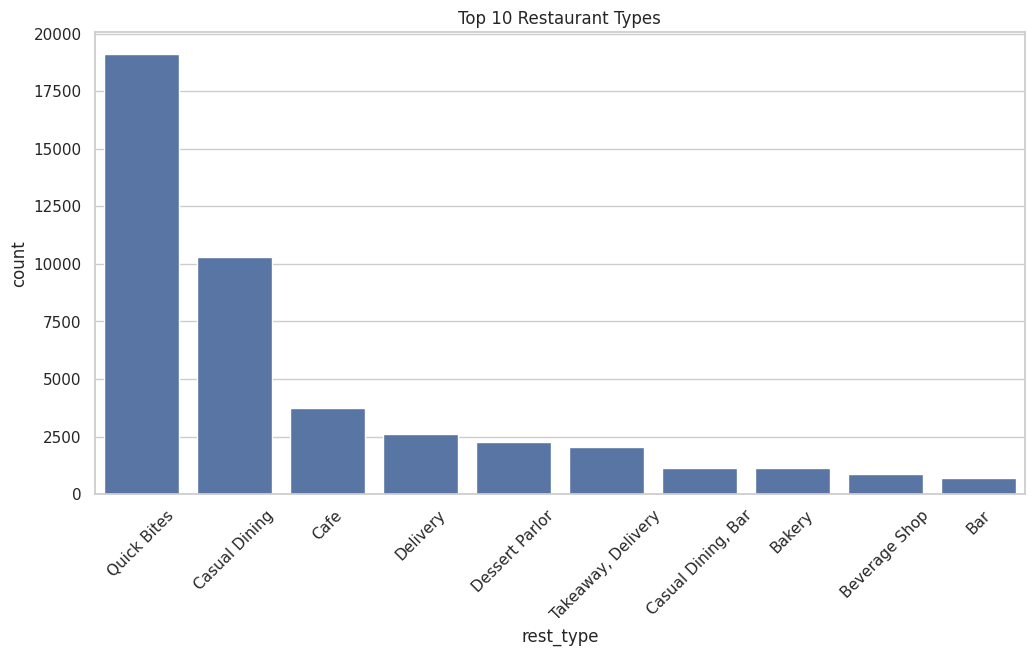

In [47]:
#Count Plot for Restaurant Types:

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rest_type', order=df['rest_type'].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title('Top 10 Restaurant Types')
plt.show()